# Dataset overview
Three views: **release timeline**, **language coverage**, and **script percentages**.
Run all cells with pandas and matplotlib installed. The CSV is read-only.

In [15]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'artifacts/dataset_inspection/history.csv').exists())
df = pd.read_csv(root / 'artifacts/dataset_inspection/history.csv', encoding='utf-8-sig', dtype=str, keep_default_na=False)
df['Completed at'] = pd.to_datetime(df['Completed at'], errors='coerce', utc=True, format='mixed')
selection = ['Dataset', 'Configuration', 'Split', 'Selected files', 'Text fields', 'Row filters']
df = df.sort_values('Completed at', na_position='first', kind='stable').drop_duplicates(selection, keep='last').copy()
df['Dataset name'] = df['Dataset'].str.replace(r'^/.*/', '', regex=True)
repeated = df['Dataset name'].duplicated(keep=False)
df.loc[repeated, 'Dataset name'] += ' · ' + df.loc[repeated, 'Text fields']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Release timeline
Only **Dataset name** and **Year/release**. Edit `release_years`; unknowns stay in the table and are omitted from the plot.
The CSV records inspection dates, not release dates. Initial sources: [Bactrian-X (2023)](https://github.com/mbzuai-nlp/bactrian-x#-news) and [Sangraha (2024)](https://ai4bharat.iitm.ac.in/blog/indicllm-suite/).

,Dataset name,Year/release
0,MBZUAI/Bactrian-X,2023
1,ai4bharat/sangraha,2024
2,Aananda-giri/gorkhapatra-nepali-epaper,Unknown
3,Boredoom17/Nepali-Corpus,Unknown
4,IRIIS-RESEARCH/Nepali-Text-Corpus,Unknown
5,Saugatkafley/alpaca-nepali-sft,Unknown
6,clean_date_categories.csv,Unknown
7,himalaya-ai/hermes-function-calling-nepali,Unknown
8,himalaya-ai/nepali-news-corpus,Unknown
9,himalaya-ai/nepali-proofreader,Unknown


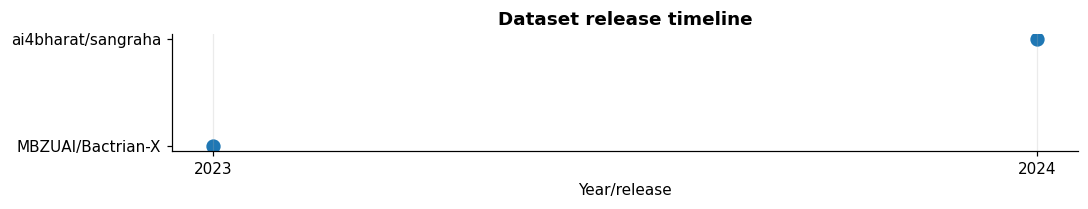

In [16]:
release_years = {'MBZUAI/Bactrian-X': 2023, 'ai4bharat/sangraha': 2024}
names = df['Dataset'].drop_duplicates()
timeline = pd.DataFrame({'Dataset name': names.str.replace(r'^/.*/', '', regex=True), 'Year/release': names.map(release_years).astype('Int64')})
timeline = timeline.sort_values(['Year/release', 'Dataset name'], na_position='last')
display(timeline.astype('string').fillna('Unknown').reset_index(drop=True))
known = timeline.dropna()
fig, ax = plt.subplots(figsize=(10, max(2, len(known) * 0.5)))
ax.scatter(known['Year/release'].astype(int), known['Dataset name'], s=70)
ax.set(xticks=sorted(known['Year/release'].unique().astype(int)), xlabel='Year/release', title='Dataset release timeline')
if known.empty: ax.text(0.5, 0.5, 'No known release years', ha='center', transform=ax.transAxes)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Parse the two percentage columns
Use the latest run per source selection. Invalid/missing breakdowns stay unavailable;
**Unreported** is the gap in older CSV percentages. Shares are not rescaled to 100%.

In [17]:
def percentages(column):
    def parse(value):
        try:
            obj = json.loads(value)
            if not isinstance(obj, dict) or not obj: return {}
            values = pd.to_numeric(pd.Series(obj), errors='coerce')
            if values.isna().any() or not values.between(0, 100).all() or not 0 < values.sum() <= 100.1: return {}
            return values.to_dict()
        except (ValueError, TypeError):
            return {}
    table = pd.DataFrame(df[column].map(parse).tolist(), index=df['Dataset name'])
    available = table.notna().any(axis=1)
    table = table.fillna(0)
    table['Unreported'] = (100 - table.sum(axis=1)).clip(lower=0).round(2)
    table.loc[~available] = float('nan')
    return table.loc[:, table.fillna(0).gt(0).any()]

## 2. Language coverage — stacked bars
Percentages of **sampled records**, including explicit Other/Unknown categories when present.

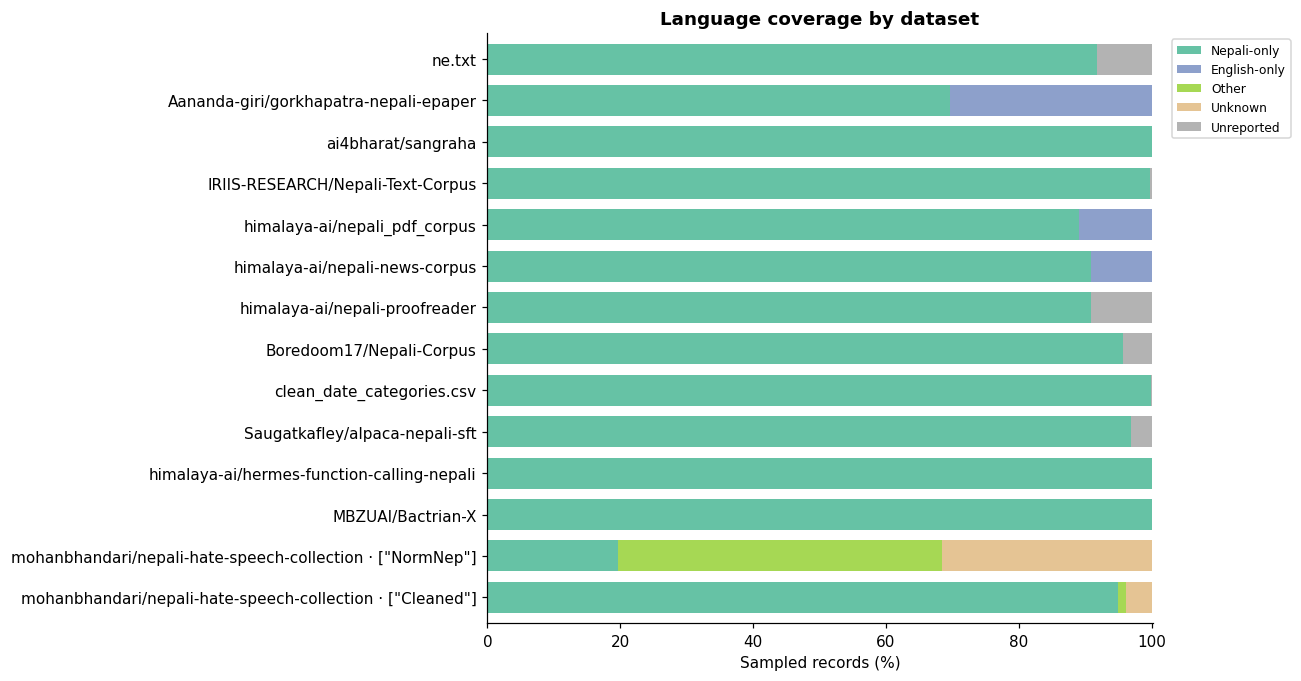

In [18]:
language = percentages('Language category %')
if not language.empty:
    ax = language.fillna(0).plot.barh(stacked=True, figsize=(12, max(4, len(language) * 0.45)), colormap='Set2', width=0.75)
    for i in range(len(language)):
        if language.iloc[i].isna().all(): ax.text(1, i, 'Unavailable', va='center', color='gray')
    ax.invert_yaxis()
    ax.set(xlim=(0, 100.1), xlabel='Sampled records (%)', ylabel='', title='Language coverage by dataset')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('No usable language percentages.')

## 3. Script — heatmap
Percentages of **Nepali-eligible records**. Gray cells are unavailable.
These percentages describe writing systems; they do not measure language detection accuracy.

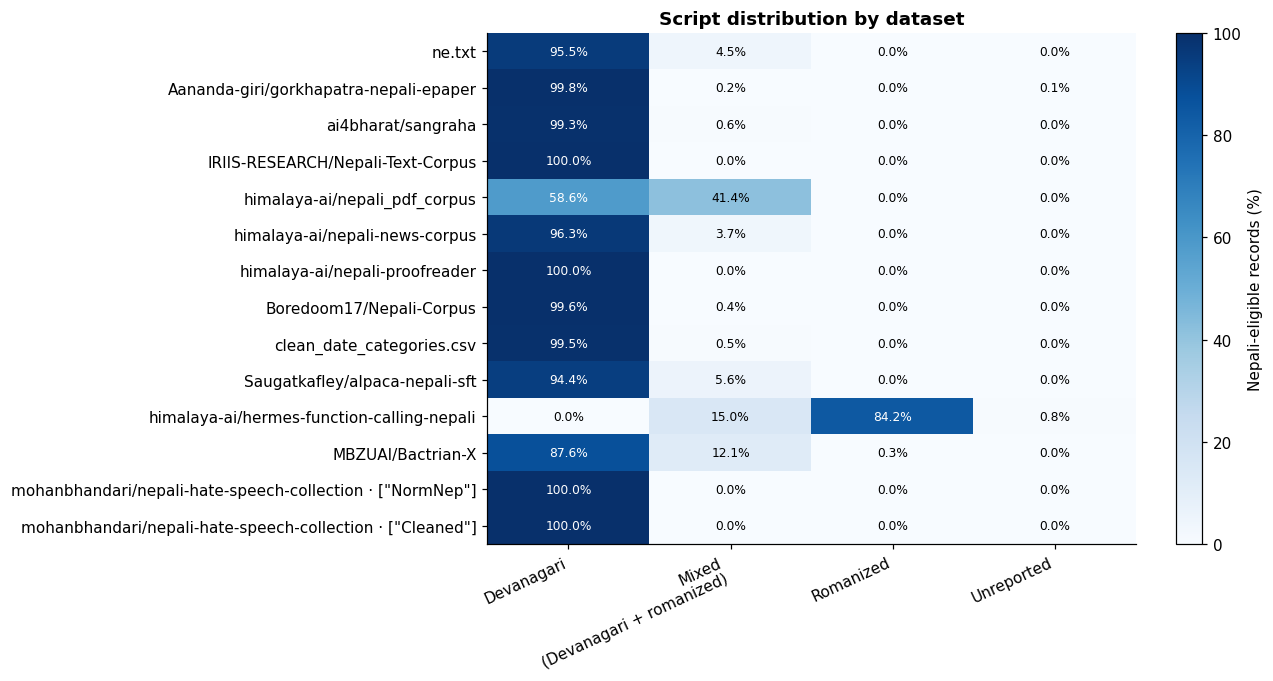

In [19]:
script = percentages('Nepali script category %')
if not script.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, len(script) * 0.45)))
    cmap = plt.get_cmap('Blues').copy()
    cmap.set_bad('#eeeeee')
    image = ax.imshow(script.to_numpy(dtype=float), aspect='auto', cmap=cmap, vmin=0, vmax=100)
    ax.set(yticks=range(len(script)), yticklabels=script.index, title='Script distribution by dataset')
    ax.set_xticks(range(len(script.columns)), script.columns.str.replace(' (', '\n(', regex=False), rotation=25, ha='right')
    for (i, j), value in pd.DataFrame(script.to_numpy()).stack().items():
        if pd.notna(value): ax.text(j, i, f'{value:.1f}%', ha='center', va='center', fontsize=8, color='white' if value > 55 else 'black')
    fig.colorbar(image, ax=ax, label='Nepali-eligible records (%)')
    plt.tight_layout()
    plt.show()
else:
    print('No usable script percentages.')